In [16]:
import os
import requests
import aiohttp
import asyncio
import nest_asyncio
import pandas as pd
import time
import scrapy
from scrapy_playwright.page import PageMethod
from bs4 import BeautifulSoup
import nest_asyncio
import glob
import numpy as np
import matplotlib.pyplot as plt
from fuzzywuzzy import fuzz, process
import re


### Lee Peng Data

In [29]:
adhoc_leads = (
    pd.read_excel('Non_MR_Leads_Le Peng.xlsx')
    .rename(columns=lambda c: c.upper().strip().replace(' ', '_').replace('-', '_'))
)
adhoc_leads.shape

(7753, 19)

In [17]:
adhoc_leads = (
    pd.read_excel('Non_MR_Leads_Le Peng.xlsx')
    .rename(columns=lambda c: c.upper().strip().replace(' ', '_').replace('-', '_'))
)

# Keep rows where at least one contact number is not NaN
cols = [f'CONTACT_NUMBER_{i}' for i in range(1, 9)]
adhoc_leads = adhoc_leads[adhoc_leads[cols].notna().any(axis=1)]

print(adhoc_leads.shape)
adhoc_leads.head(5)


(4230, 19)


,COMPANY_NAME,PIC_NAME,DESIGNATION,CONTACT_NUMBER_1,CONTACT_NUMBER_2,CONTACT_NUMBER_3,CONTACT_NUMBER_4,CONTACT_NUMBER_5,CONTACT_NUMBER_6,CONTACT_NUMBER_7,CONTACT_NUMBER_8,ADDRESS,EMAIL_1,EMAIL_2,EMAIL_3,EMAIL_4,EMAIL_5,EMAIL_6,EMAIL_7
0,TAMJAI SAMGOR MIXIAN,Micky Gan,NaN,65 6513 1787,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,micky.gan@tamjai-inti.com.sg,NaN,NaN,NaN,NaN,NaN,NaN
2,FORINTECH,Ian Li,NaN,65 8132 3868,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ian.li@forintechasia.com,NaN,NaN,NaN,NaN,NaN,NaN
4,THE DENZY COLLECTIVE,Kelvin Toh,NaN,65 9386 4782,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,kel@denzy.com,NaN,NaN,NaN,NaN,NaN,NaN
5,INTERNATIONAL FOODGNOSTIC,Richard Tay,NaN,65 9687 4191,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,richard_tay@foodgnostic.com,NaN,NaN,NaN,NaN,NaN,NaN
6,HOSANNA FREIGHT AND LOGISTICS PTE LTD,Yanti,NaN,65 9677 8810,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,yanti.tang@hosannafreight.com.sg,NaN,NaN,NaN,NaN,NaN,NaN


### Getting Acra Data 

In [18]:

folder_path = "Acra_Data"

# Get all CSV file paths inside the folder
csv_files = glob.glob(os.path.join(folder_path, "*.csv"))

# Read and combine all CSVs
# Using low_memory=False to avoid DtypeWarning for mixed types
df = pd.concat((pd.read_csv(f, low_memory=False) for f in csv_files), ignore_index=True)


df.columns = df.columns.str.upper()


acra_data = df[[
    "UEN",
    "ENTITY_NAME",
    "BUSINESS_CONSTITUTION_DESCRIPTION",
    "ENTITY_TYPE_DESCRIPTION",
    "ENTITY_STATUS_DESCRIPTION",
    "REGISTRATION_INCORPORATION_DATE",
    "PRIMARY_SSIC_CODE",
    "SECONDARY_SSIC_CODE",
    "STREET_NAME",
    "POSTAL_CODE"
]].copy()

# Convert to proper data types
acra_data['UEN'] = acra_data['UEN'].astype('string')
acra_data['ENTITY_NAME'] = acra_data['ENTITY_NAME'].astype('string')
acra_data['BUSINESS_CONSTITUTION_DESCRIPTION'] = acra_data['BUSINESS_CONSTITUTION_DESCRIPTION'].astype('string')
acra_data['ENTITY_TYPE_DESCRIPTION'] = acra_data['ENTITY_TYPE_DESCRIPTION'].astype('string')
acra_data['ENTITY_STATUS_DESCRIPTION'] = acra_data['ENTITY_STATUS_DESCRIPTION'].astype('string')
acra_data['REGISTRATION_INCORPORATION_DATE'] = pd.to_datetime(acra_data['REGISTRATION_INCORPORATION_DATE'], errors='coerce')

# Clean string columns — trim, remove extra spaces, uppercase
for col in [
    'UEN',
    'ENTITY_NAME',
    'BUSINESS_CONSTITUTION_DESCRIPTION',
    'ENTITY_TYPE_DESCRIPTION',
    'ENTITY_STATUS_DESCRIPTION',
    'STREET_NAME',
    'POSTAL_CODE'
]:
    acra_data[col] = (
        acra_data[col]
        .fillna('')
        .str.strip()
        .str.replace(r'\s+', ' ', regex=True)
        .str.upper()
    )

# Replace placeholders with NaN for standardization
acra_data.replace(['NA', 'N/A', '-', ''], np.nan, inplace=True)

# Convert registration date to dd-mm-yyyy string (optional)
acra_data['REGISTRATION_INCORPORATION_DATE'] = acra_data['REGISTRATION_INCORPORATION_DATE'].dt.strftime('%d-%m-%Y')

# Filter only live entities (LIVE COMPANY or LIVE)
acra_data = acra_data[
    acra_data['ENTITY_STATUS_DESCRIPTION'].isin(['LIVE COMPANY', 'LIVE'])
].reset_index(drop=True)

# Exclude specific PRIMARY_SSIC_CODE values (supposedly the data would be 600k plus but when we exclude this would lessen)
exclude_codes = [
    46900, 47719, 47749, 47539, 47536, 56123,
    10711, 10712, 10719, 10732, 10733, 93209
]

acra_data = acra_data[~acra_data['PRIMARY_SSIC_CODE'].isin(exclude_codes)].reset_index(drop=True)

In [19]:
acra_data.head(5)

,UEN,ENTITY_NAME,BUSINESS_CONSTITUTION_DESCRIPTION,ENTITY_TYPE_DESCRIPTION,ENTITY_STATUS_DESCRIPTION,REGISTRATION_INCORPORATION_DATE,PRIMARY_SSIC_CODE,SECONDARY_SSIC_CODE,STREET_NAME,POSTAL_CODE
0,00182000A,AIK SENG HENG,PARTNERSHIP,SOLE PROPRIETORSHIP/ PARTNERSHIP,LIVE,07-02-1975,46302,na,FISHERY PORT ROAD,619742
1,00233500W,ASIA STORE,PARTNERSHIP,SOLE PROPRIETORSHIP/ PARTNERSHIP,LIVE,28-10-1974,46411,20234,SIMS AVENUE,387509
2,00733000J,AIK CHE HIONG,PARTNERSHIP,SOLE PROPRIETORSHIP/ PARTNERSHIP,LIVE,02-11-1974,32909,46900,ANG MO KIO INDUSTRIAL PARK 2A,568049
3,00927000X,A WALIMOHAMED BROS,PARTNERSHIP,SOLE PROPRIETORSHIP/ PARTNERSHIP,LIVE,12-11-1974,46411,66126,JELLICOE ROAD,208767
4,01173000E,ANG TECK MOH DEPARTMENT STORE,PARTNERSHIP,SOLE PROPRIETORSHIP/ PARTNERSHIP,LIVE,30-10-1974,47711,47214,WOODLANDS STREET 12,738623


In [20]:
acra_names = acra_data[["ENTITY_NAME"]]

In [21]:
adhoc_leads

,COMPANY_NAME,PIC_NAME,DESIGNATION,CONTACT_NUMBER_1,CONTACT_NUMBER_2,CONTACT_NUMBER_3,CONTACT_NUMBER_4,CONTACT_NUMBER_5,CONTACT_NUMBER_6,CONTACT_NUMBER_7,CONTACT_NUMBER_8,ADDRESS,EMAIL_1,EMAIL_2,EMAIL_3,EMAIL_4,EMAIL_5,EMAIL_6,EMAIL_7
0,TAMJAI SAMGOR MIXIAN,Micky Gan,NaN,65 6513 1787,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,micky.gan@tamjai-inti.com.sg,NaN,NaN,NaN,NaN,NaN,NaN
2,FORINTECH,Ian Li,NaN,65 8132 3868,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ian.li@forintechasia.com,NaN,NaN,NaN,NaN,NaN,NaN
4,THE DENZY COLLECTIVE,Kelvin Toh,NaN,65 9386 4782,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,kel@denzy.com,NaN,NaN,NaN,NaN,NaN,NaN
5,INTERNATIONAL FOODGNOSTIC,Richard Tay,NaN,65 9687 4191,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,richard_tay@foodgnostic.com,NaN,NaN,NaN,NaN,NaN,NaN
6,HOSANNA FREIGHT AND LOGISTICS PTE LTD,Yanti,NaN,65 9677 8810,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,yanti.tang@hosannafreight.com.sg,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7746,NaN,Amaran,Deputy General Manager,65 9855 6557,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ran@jeewa.sg,NaN,NaN,NaN,NaN,NaN,NaN
7747,NaN,Karen Boey,Owner,65 8144 1148,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,karen@collectivegoodness.com,NaN,NaN,NaN,NaN,NaN,NaN
7748,NaN,Peter Alnaimi,GM,65 9445 0500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Peter@kebab.sg,NaN,NaN,NaN,NaN,NaN,NaN
7750,NaN,Tan Teng Sern,NaN,65 9768 1249,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,tengsern.tan@ucgroup.sg,NaN,NaN,NaN,NaN,NaN,NaN


In [22]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

def preprocess_company_name(name):
    """
    OPTIMIZED preprocessing for company names.
    Removes common suffixes, special characters, and standardizes format.
    """
    if pd.isna(name):
        return ""

    name = str(name).upper().strip()
    name = re.sub(r'[^\w\s]', ' ', name)

    suffixes = [
        'PRIVATE LIMITED', 'PTE LTD', 'PTE. LTD.', 'PTE LTD.', 'PTE. LTD',
        'PVT LTD', 'LIMITED', 'LTD', 'SINGAPORE', 'S.G.', 'SG', 'PTE',
        'COMPANY', 'CO', 'CORPORATION', 'CORP', 'INC', 'INCORPORATED',
        'LLC', 'LLP', 'PROPRIETARY', 'PROP'
    ]

    for suffix in suffixes:
        if name.endswith(' ' + suffix):
            name = name[:-len(suffix)-1].strip()
        elif name == suffix:
            name = ""

    name = re.sub(r'\s+', ' ', name).strip()
    return name

# Preprocess both datasets
company_names_clean = adhoc_leads['COMPANY_NAME'].apply(preprocess_company_name)
acra_names_clean = acra_names['ENTITY_NAME'].apply(preprocess_company_name)

# OPTIMIZED TF-IDF Vectorizer
vectorizer = TfidfVectorizer(
    analyzer='char_wb',
    ngram_range=(2, 5),
    lowercase=True,
    max_df=0.90,
    min_df=1,
    strip_accents='unicode',
    sublinear_tf=True
)

# Fit and transform
all_names = pd.concat([company_names_clean, acra_names_clean], ignore_index=True)
vectorizer.fit(all_names)
tfidf_company = vectorizer.transform(company_names_clean)
tfidf_acra = vectorizer.transform(acra_names_clean)

# ============================================================================
# OPTIMIZED MEMORY-EFFICIENT BATCH PROCESSING
# ============================================================================
BATCH_SIZE = 100
PERFECT_THRESHOLD = 1.00
HIGH_QUALITY_THRESHOLD = 0.85

match_results = []
total_batches = (len(adhoc_leads) + BATCH_SIZE - 1) // BATCH_SIZE

for batch_num in range(total_batches):
    start_idx = batch_num * BATCH_SIZE
    end_idx = min(start_idx + BATCH_SIZE, len(adhoc_leads))

    batch_similarities = cosine_similarity(tfidf_company[start_idx:end_idx], tfidf_acra)

    for i, company_idx in enumerate(range(start_idx, end_idx)):
        scores = batch_similarities[i]
        best_acra_idx = np.argmax(scores)
        best_score = scores[best_acra_idx]

        match_results.append({
            'company_idx': company_idx,
            'ENTITY_NAME': acra_data.iloc[best_acra_idx]['ENTITY_NAME'],
            'UEN': acra_data.iloc[best_acra_idx]['UEN'],
            'SIMILARITY_SCORE': round(best_score, 4)
        })

# Create match results dataframe and merge with adhoc_leads
match_df = pd.DataFrame(match_results)

# Merge to maintain all columns from adhoc_leads
adhoc_leads_with_matches = adhoc_leads.copy()
adhoc_leads_with_matches['ENTITY_NAME'] = match_df['ENTITY_NAME'].values
adhoc_leads_with_matches['UEN'] = match_df['UEN'].values
adhoc_leads_with_matches['SIMILARITY_SCORE'] = match_df['SIMILARITY_SCORE'].values

# Create 3-tier dataframes
perfect_match_df = adhoc_leads_with_matches[
    adhoc_leads_with_matches['SIMILARITY_SCORE'] == PERFECT_THRESHOLD
].reset_index(drop=True)

high_quality_df = adhoc_leads_with_matches[
    (adhoc_leads_with_matches['SIMILARITY_SCORE'] >= HIGH_QUALITY_THRESHOLD) &
    (adhoc_leads_with_matches['SIMILARITY_SCORE'] < PERFECT_THRESHOLD)
].reset_index(drop=True)

low_quality_df = adhoc_leads_with_matches[
    adhoc_leads_with_matches['SIMILARITY_SCORE'] < HIGH_QUALITY_THRESHOLD
].reset_index(drop=True)

# Final summary
print(f"\n{'='*70}")
print("DATAFRAMES CREATED:")
print(f"{'='*70}")
print(f"  perfect_match_df : {len(perfect_match_df):,} rows (100% similarity)")
print(f"  high_quality_df  : {len(high_quality_df):,} rows (85%-99% similarity)")
print(f"  low_quality_df   : {len(low_quality_df):,} rows (<85% similarity)")


DATAFRAMES CREATED:
  perfect_match_df : 339 rows (100% similarity)
  high_quality_df  : 1,138 rows (85%-99% similarity)
  low_quality_df   : 2,753 rows (<85% similarity)


In [30]:
perfect_match_df[["COMPANY_NAME", "ENTITY_NAME", "SIMILARITY_SCORE", "UEN"]].head(10)

,COMPANY_NAME,ENTITY_NAME,SIMILARITY_SCORE,UEN
0,ASIAWORLD DEVELOPMENTS,ASIAWORLD DEVELOPMENTS,1.0,52926335A
1,SAKABA EIZOU,SAKABA EIZOU,1.0,53458436E
2,BROADWAY,BROADWAY CO,1.0,07119000K
3,ARTANS HOUSE,ARTANS HOUSE LLP,1.0,T16LL1881F
4,IFS CAPITAL,IFS CAPITAL LIMITED,1.0,198700827C
5,ERA,ERA SINGAPORE PTE LTD,1.0,199003777Z
6,AAA MOKITA FOOD MANAGEMENT & CATERING PTE. LTD.,AAA MOKITA FOOD MANAGEMENT & CATERING PTE. LTD.,1.0,202012747H
7,ABR HOLDINGS LIMITED,ABR HOLDINGS LIMITED,1.0,197803023H
8,BEST HAWA RESTAURANT CHICKEN RICE & SEAFOOD,BEST HAWA RESTAURANT CHICKEN RICE & SEAFOOD,1.0,52966167E
9,CHAREN THAI KITCHEN,CHAREN THAI KITCHEN,1.0,53410519W


In [25]:
high_quality_df[["COMPANY_NAME", "ENTITY_NAME", "SIMILARITY_SCORE"]].head(10)

,COMPANY_NAME,ENTITY_NAME,SIMILARITY_SCORE
0,INTERNATIONAL FOODGNOSTIC,INTERNATIONAL FOODGNOSTICS CORPORATION PTE. LTD.,0.8505
1,HOSANNA FREIGHT AND LOGISTICS PTE LTD,HOSANNA FREIGHT & LOGISTICS PTE. LTD.,0.9715
2,YAMATO IZAKAYA,YAMATO IZAKAYA (PTE. LTD.),0.9936
3,FOOD JOY,FOOD-JOY PTE. LTD.,0.9759
4,TIONG HOE SPECIALTY COFFEE,TIONG HOE SPECIALTY COFFEE PTE. LTD.,0.9940
5,WOK HEY,WOK HEY PTE. LTD.,0.9813
6,EG INNOVATIONS,EG INNOVATIONS PTE. LTD.,0.9853
7,WESTLAKE,WESTLAKE 3 PTE. LTD.,0.9531
8,MR KNEADY,MR. KNEADY'S,0.9914
9,BBQ MASTER,BBQ MASTER PTE. LTD.,0.9855


In [26]:
low_quality_df[["COMPANY_NAME", "ENTITY_NAME", "SIMILARITY_SCORE"]].head(10)

,COMPANY_NAME,ENTITY_NAME,SIMILARITY_SCORE
0,TAMJAI SAMGOR MIXIAN,SAMGOR SERVICES PTE. LTD.,0.5474
1,FORINTECH,FORINTECH INTERNATIONAL PTE. LTD.,0.7967
2,THE DENZY COLLECTIVE,THE S COLLECTIVE PTE. LTD.,0.6896
3,EVERY INTL,EVERY TECH PTE. LTD.,0.5799
4,LÄDERACH CHOCOLATIER,GODIVA CHOCOLATIER (ASIA) LIMITED,0.5811
5,SHINAGI,AVPVI INAGI SG HOLDING PTE. LTD.,0.4111
6,TOHO SINGAPORE,TOHO GAS SINGAPORE PTE. LTD.,0.7101
7,NIVEKEN PTE LTD,NIVEK TRADING,0.5172
8,RESTAURANT BRANDS INTERNATIONAL,INTERNATIONAL BRANDS PTE LTD,0.7791
9,MINTPLUS,PRINTPLUS DESIGN SERVICES,0.6255


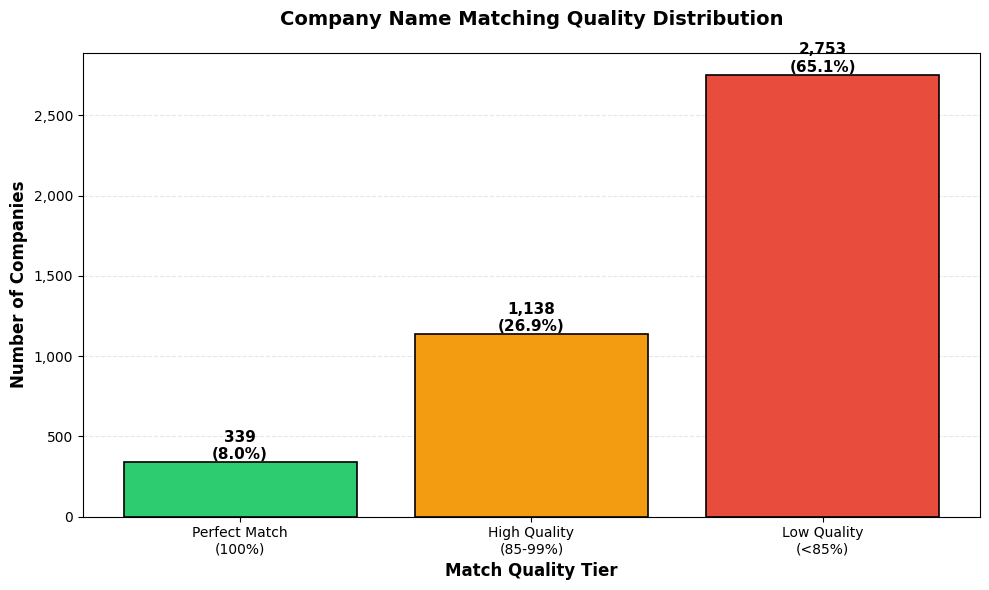


Total companies processed: 4,230


In [27]:
# Create column chart for match quality distribution
import matplotlib.pyplot as plt

# Prepare data
categories = ['Perfect Match\n(100%)', 'High Quality\n(85-99%)', 'Low Quality\n(<85%)']
counts = [len(perfect_match_df), len(high_quality_df), len(low_quality_df)]
percentages = [
    (len(perfect_match_df) / len(adhoc_leads)) * 100,
    (len(high_quality_df) / len(adhoc_leads)) * 100,
    (len(low_quality_df) / len(adhoc_leads)) * 100
]

# Create figure
fig, ax = plt.subplots(figsize=(10, 6))

# Create bars with custom colors
colors = ['#2ecc71', '#f39c12', '#e74c3c']
bars = ax.bar(categories, counts, color=colors, edgecolor='black', linewidth=1.2)

# Add value labels on top of bars
for i, (bar, count, pct) in enumerate(zip(bars, counts, percentages)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{count:,}\n({pct:.1f}%)',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

# Customize chart
ax.set_ylabel('Number of Companies', fontsize=12, fontweight='bold')
ax.set_xlabel('Match Quality Tier', fontsize=12, fontweight='bold')
ax.set_title('Company Name Matching Quality Distribution', fontsize=14, fontweight='bold', pad=20)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)

# Format y-axis
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))

plt.tight_layout()
plt.show()

print(f"\nTotal companies processed: {len(adhoc_leads):,}")

In [ ]:
https://recordowl.com/search?name={name of the business}

In [ ]:
low_quality_df